# OUSD Chronic Absenteeism — End-to-End Pipeline

Single-notebook walkthrough of the full modeling pipeline:

1. Load cleaned student data (`data/evaldata_cleaned.csv`)
2. Build a multi-class chronic-absenteeism target
3. Re-join crime and socioeconomic data on `(Zip, year)`
4. Engineer prior-year features (attendance history, trends, school aggregates, demographics, neighborhood)
5. Temporal train/test split (train: 1920–2223, test: 2324)
6. Two baselines that require no missing data:
   - **Linear regression** → continuous `AttRate`
   - **Multinomial logistic regression** → categorical `chronic_level`
7. Advanced classifiers that tolerate missing values:
   - **Decision Tree**, **Random Forest**, **XGBoost**, **CatBoost**
8. Model comparison and feature importance

## 0. Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score,
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = REPO_ROOT / 'data'
print('Data dir:', DATA_DIR)

Data dir: /Users/gaoqianwen/ousd-absence-prediction/data


## 1. Load cleaned student data

`evaldata_cleaned.csv` is in long format: one row per student per school year. Each year code like `2324` means school year 2023–24.

In [2]:
raw = pd.read_csv(DATA_DIR / 'evaldata_cleaned.csv')
print(f'Rows: {len(raw):,}')
print(f'Unique students: {raw["ANON_ID"].nunique():,}')
print(f'Years: {sorted(raw["year"].unique())}')
raw.head()

Rows: 256,865
Unique students: 36,695
Years: [np.int64(1718), np.int64(1819), np.int64(1920), np.int64(2021), np.int64(2122), np.int64(2223), np.int64(2324)]


,ANON_ID,Birthdate,Gen,Eth,Fluency,SpEd,SiteName,Zip,Grade,AttRate,DaysEnr,DaysAbs,Susp,CurrWeightedTotGPA,SED,year,chronic_absent,total_crimes,violent_crimes,property_crimes,drug_crimes,other_crimes,total_population,poverty_rate_pct,median_household_income,unemployment_rate_pct,high_school_plus_rate_pct,college_degree_rate_pct,median_gross_rent,median_home_value,uninsured_rate_pct
0,3,2019-05-09,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5,2016-01-26,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6,2018-11-16,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11,2017-02-22,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,12,2016-02-18,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Drop the pre-merged crime/SES columns so we can re-join them transparently in §3
ext_cols = ['total_crimes', 'violent_crimes', 'property_crimes', 'drug_crimes', 'other_crimes',
            'total_population', 'poverty_rate_pct', 'median_household_income',
            'unemployment_rate_pct', 'high_school_plus_rate_pct', 'college_degree_rate_pct',
            'median_gross_rent', 'median_home_value', 'uninsured_rate_pct']
df = raw.drop(columns=[c for c in ext_cols if c in raw.columns])
print(f'Kept {df.shape[1]} columns after dropping pre-merged external features')
df.dtypes

Kept 17 columns after dropping pre-merged external features


ANON_ID                 int64
Birthdate              object
Gen                    object
Eth                    object
Fluency                object
SpEd                   object
SiteName               object
Zip                   float64
Grade                 float64
AttRate               float64
DaysEnr               float64
DaysAbs               float64
Susp                  float64
CurrWeightedTotGPA    float64
SED                    object
year                    int64
chronic_absent        float64
dtype: object

In [4]:
# Quick EDA: rows per year, AttRate distribution, chronic rate
per_year = df.groupby('year').agg(
    rows=('ANON_ID', 'size'),
    enrolled=('AttRate', lambda s: s.notna().sum()),
    mean_attrate=('AttRate', 'mean'),
    chronic_rate=('chronic_absent', 'mean'),
).round(3)
per_year

,rows,enrolled,mean_attrate,chronic_rate
year,,,,
1718,36695,11227,0.950,0.117
1819,36695,13902,0.911,0.282
1920,36695,16675,0.945,0.144
2021,36695,19307,0.939,0.158
2122,36695,23383,0.882,0.406
2223,36695,29021,0.856,0.563
2324,36695,35917,0.893,0.321


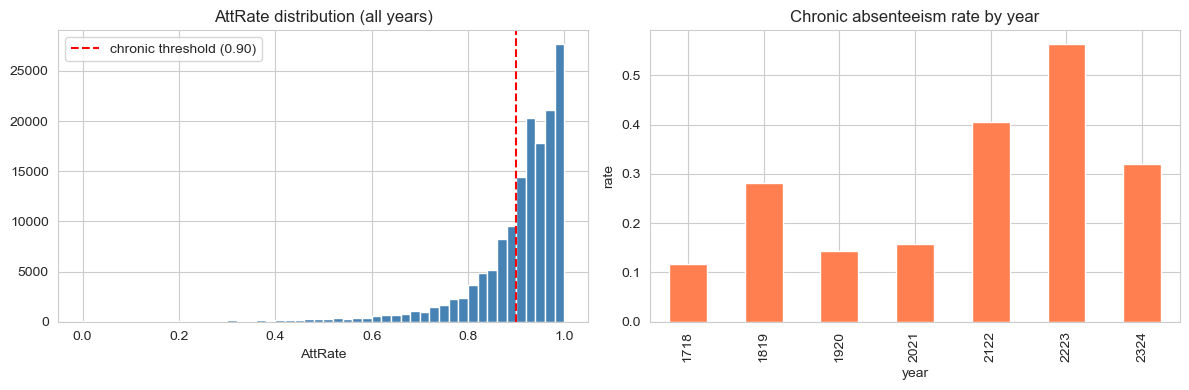

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['AttRate'].dropna().hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('AttRate distribution (all years)')
axes[0].set_xlabel('AttRate')
axes[0].axvline(0.90, color='red', linestyle='--', label='chronic threshold (0.90)')
axes[0].legend()

per_year['chronic_rate'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Chronic absenteeism rate by year')
axes[1].set_ylabel('rate')
plt.tight_layout()
plt.show()

## 2. Build the categorical target `chronic_level`

| Level | AttRate range | Meaning |
|---|---|---|
| 0 | ≥ 0.96 | Satisfactory |
| 1 | 0.90–0.96 | At-risk |
| 2 | 0.80–0.90 | Moderately chronic |
| 3 | < 0.80 | Severely chronic |

In [6]:
CHRONIC_BINS = [-np.inf, 0.80, 0.90, 0.96, np.inf]
CHRONIC_LABELS = [3, 2, 1, 0]  # left→right: severe, moderate, at-risk, satisfactory
LEVEL_NAMES = {0: 'Satisfactory', 1: 'At-risk', 2: 'Moderately chronic', 3: 'Severely chronic'}

def to_level(att_rate):
    return pd.cut(att_rate, bins=CHRONIC_BINS, labels=CHRONIC_LABELS).astype('float')

df['chronic_level'] = to_level(df['AttRate'])

# Sanity: levels 2+3 should equal the binary chronic_absent flag
check = df.dropna(subset=['AttRate']).copy()
check['level_chronic'] = (check['chronic_level'] >= 2).astype(int)
agree = (check['level_chronic'] == check['chronic_absent']).mean()
print(f'Agreement between level_chronic and chronic_absent: {agree*100:.2f}%')
print('\nLevel counts:')
print(df['chronic_level'].value_counts().sort_index().rename(LEVEL_NAMES))

Agreement between level_chronic and chronic_absent: 98.52%

Level counts:
chronic_level
Satisfactory          48712
At-risk               50463
Moderately chronic    33040
Severely chronic      17217
Name: count, dtype: int64


## 3. Re-join crime and socioeconomic data on `(Zip, year)`

Both external files key on `zip_code` and `year`. Only ~17 Oakland ZCTAs are covered, so students outside those ZIPs will have NaN external features after the left join — that's expected.

In [7]:
crime = pd.read_csv(DATA_DIR / 'oakland_crime_by_zip.csv')
socio = pd.read_csv(DATA_DIR / 'oakland_socioeconomic_by_zip.csv')
print(f'Crime: {crime.shape}, Socio: {socio.shape}')
display(crime.head(2))
display(socio.head(2))

Crime: (144, 7), Socio: (120, 18)


,year,zip_code,total_crimes,violent_crimes,property_crimes,drug_crimes,other_crimes
0,2017,94601,4749,1325,1434,168,1822
1,2017,94602,1881,231,673,25,952


,year,zip_code,area_name,total_population,poverty_universe,below_poverty,poverty_rate_pct,median_household_income,labor_force,unemployed,unemployment_rate_pct,education_universe_25plus,high_school_plus_rate_pct,college_degree_rate_pct,median_gross_rent,median_home_value,health_insurance_universe,uninsured_rate_pct
0,2017,94601,ZCTA5 94601,50763,50201,13740,27.4,44666,25992,2570,9.9,32999,45.5,19.6,1145,364500,50455,82.1
1,2017,94602,ZCTA5 94602,30098,29986,3450,11.5,78347,16457,1225,7.4,21787,67.5,50.0,1286,673100,30022,93.4


In [8]:
# External data years are calendar years (e.g. 2017). evaldata year codes are 1718, 1819, ...
# Map calendar year → school year code (e.g. 2017 → 1718 meaning school year 2017-18).
def cal_to_school_year(cy):
    yy1 = cy % 100
    yy2 = (cy + 1) % 100
    return yy1 * 100 + yy2

crime['year'] = crime['year'].apply(cal_to_school_year)
socio['year'] = socio['year'].apply(cal_to_school_year)

# Normalize zip types (both sides to numeric, then left-join)
df['Zip'] = pd.to_numeric(df['Zip'], errors='coerce')
crime['zip_code'] = pd.to_numeric(crime['zip_code'], errors='coerce')
socio['zip_code'] = pd.to_numeric(socio['zip_code'], errors='coerce')

df = df.merge(
    crime, left_on=['Zip', 'year'], right_on=['zip_code', 'year'], how='left'
).drop(columns=['zip_code'])
df = df.merge(
    socio.drop(columns=['area_name']),
    left_on=['Zip', 'year'], right_on=['zip_code', 'year'], how='left'
).drop(columns=['zip_code'])

match_rate = df['total_crimes'].notna().mean()
print(f'Crime/SES match rate: {match_rate*100:.1f}% of all student-year rows')
print(f'Total columns now: {df.shape[1]}')

Crime/SES match rate: 59.2% of all student-year rows
Total columns now: 38


## 4. Feature engineering — prior-year features

Mirrors `scripts/feature_engineering.py:31-158`. For each target year we build one row per student enrolled in that year, using **only** data from years before the target. This is the critical no-leakage constraint.

Feature blocks:
- `prev_*` — most recent prior year
- `prev2_*` — second most recent prior year
- `prior_*` — multi-year aggregates
- `att_rate_slope`, `att_rate_yoy_change` — trends
- `school_*` — school-level aggregates from last prior year
- one-hot demographics, `age`
- neighborhood crime/SES from the target year

In [9]:
def compute_slope(values):
    vals = values.dropna()
    if len(vals) < 2:
        return 0.0
    x = np.arange(len(vals))
    return np.polyfit(x, vals.values, 1)[0]


NEIGH_COLS = [
    'total_crimes', 'violent_crimes', 'property_crimes', 'drug_crimes', 'other_crimes',
    'total_population', 'poverty_rate_pct', 'median_household_income',
    'unemployment_rate_pct', 'high_school_plus_rate_pct', 'college_degree_rate_pct',
    'median_gross_rent', 'median_home_value', 'uninsured_rate_pct',
]


def build_prior_year_features(df_all, target_year):
    all_years = sorted(df_all['year'].unique())
    prior_years = [y for y in all_years if y < target_year]

    target_rows = df_all[(df_all['year'] == target_year) & df_all['AttRate'].notna()].copy()
    target_ids = set(target_rows['ANON_ID'])

    prior = df_all[(df_all['ANON_ID'].isin(target_ids))
                   & (df_all['year'].isin(prior_years))
                   & df_all['AttRate'].notna()].copy()

    # ---- Most recent prior year ----
    last_prior_year = prior_years[-1]
    last_year = prior[prior['year'] == last_prior_year][
        ['ANON_ID', 'AttRate', 'DaysAbs', 'DaysEnr', 'Susp', 'chronic_absent',
         'CurrWeightedTotGPA', 'Grade']
    ].copy()
    last_year.columns = ['ANON_ID', 'prev_att_rate', 'prev_days_abs', 'prev_days_enr',
                         'prev_susp', 'prev_chronic', 'prev_gpa', 'prev_grade']

    # ---- 2nd most recent prior year ----
    if len(prior_years) >= 2:
        second_prior_year = prior_years[-2]
        second_year = prior[prior['year'] == second_prior_year][['ANON_ID', 'AttRate', 'chronic_absent']].copy()
        second_year.columns = ['ANON_ID', 'prev2_att_rate', 'prev2_chronic']
        last_year = last_year.merge(second_year, on='ANON_ID', how='left')

    # ---- Multi-year aggregates ----
    multi = prior.groupby('ANON_ID').agg(
        prior_mean_att_rate=('AttRate', 'mean'),
        prior_min_att_rate=('AttRate', 'min'),
        prior_max_susp=('Susp', 'max'),
        prior_total_susp=('Susp', 'sum'),
        prior_chronic_count=('chronic_absent', 'sum'),
        prior_years_enrolled=('year', 'count'),
        prior_mean_gpa=('CurrWeightedTotGPA', 'mean'),
    ).reset_index()

    att_slope = prior.sort_values('year').groupby('ANON_ID')['AttRate'].apply(compute_slope).reset_index()
    att_slope.columns = ['ANON_ID', 'att_rate_slope']

    if len(prior_years) >= 2:
        last2 = prior[prior['year'].isin(prior_years[-2:])].sort_values('year')
        yoy = last2.groupby('ANON_ID')['AttRate'].apply(
            lambda x: x.iloc[-1] - x.iloc[0] if len(x) == 2 else np.nan
        ).reset_index()
        yoy.columns = ['ANON_ID', 'att_rate_yoy_change']
    else:
        yoy = pd.DataFrame({'ANON_ID': list(target_ids), 'att_rate_yoy_change': np.nan})

    # ---- School-level aggregates from last prior year ----
    prior_last = df_all[(df_all['year'] == last_prior_year) & df_all['AttRate'].notna()]
    school_agg = prior_last.groupby('SiteName').agg(
        school_chronic_rate=('chronic_absent', 'mean'),
        school_mean_att=('AttRate', 'mean'),
        school_size=('ANON_ID', 'count'),
        school_mean_susp=('Susp', 'mean'),
    ).reset_index()
    target_school = target_rows[['ANON_ID', 'SiteName']].merge(school_agg, on='SiteName', how='left')
    target_school = target_school.drop(columns=['SiteName'])

    # ---- Demographics (target-year row) ----
    target_demo = target_rows[['ANON_ID', 'Gen', 'Eth', 'Fluency', 'SpEd', 'SED', 'Grade', 'Zip']].copy()

    birth = target_rows[['ANON_ID', 'Birthdate']].copy()
    birth['Birthdate'] = pd.to_datetime(birth['Birthdate'], errors='coerce')
    cal_year = 2000 + target_year // 100
    birth['age'] = cal_year - birth['Birthdate'].dt.year
    birth = birth[['ANON_ID', 'age']]

    # ---- Neighborhood (target-year row, from §3 join) ----
    available_neigh = [c for c in NEIGH_COLS if c in target_rows.columns]
    target_neigh = target_rows[['ANON_ID'] + available_neigh].copy()

    # ---- Targets (regression + classification) ----
    target_var = target_rows[['ANON_ID', 'AttRate', 'chronic_absent', 'chronic_level']].copy()

    # ---- Merge everything ----
    feats = target_demo
    for r in [birth, last_year, multi, att_slope, yoy, target_school, target_neigh, target_var]:
        feats = feats.merge(r, on='ANON_ID', how='left')

    # One-hot encode categorical demographics
    for c in ['Gen', 'Eth', 'Fluency', 'SpEd', 'SED']:
        feats[c] = feats[c].fillna('Unknown')
    feats = pd.get_dummies(feats, columns=['Gen', 'Eth', 'Fluency', 'SpEd', 'SED'],
                           drop_first=False, dtype=int)

    feats['has_prior_data'] = feats['prev_att_rate'].notna().astype(int)
    feats['has_prior2_data'] = feats.get('prev2_att_rate', pd.Series(dtype=float)).notna().astype(int)
    feats['target_year'] = target_year
    return feats

In [10]:
TARGET_YEARS = [1920, 2021, 2122, 2223, 2324]
frames = []
for ty in TARGET_YEARS:
    f = build_prior_year_features(df, ty)
    print(f'year {ty}: {len(f):,} rows, {f.shape[1]} cols, '
          f'has_prior={f["has_prior_data"].mean()*100:.1f}%, '
          f'chronic={f["chronic_absent"].mean()*100:.1f}%')
    frames.append(f)

# Align columns (some dummies may differ year to year)
all_cols = set()
for f in frames:
    all_cols.update(f.columns)
for i, f in enumerate(frames):
    for c in all_cols - set(f.columns):
        frames[i][c] = 0
cols = sorted(all_cols)
frames = [f[cols] for f in frames]

year 1920: 16,675 rows, 67 cols, has_prior=80.2%, chronic=14.4%


year 2021: 19,307 rows, 67 cols, has_prior=83.6%, chronic=15.8%


year 2122: 23,383 rows, 68 cols, has_prior=79.1%, chronic=40.6%


year 2223: 29,021 rows, 69 cols, has_prior=79.4%, chronic=56.3%


year 2324: 35,917 rows, 69 cols, has_prior=79.7%, chronic=32.1%


In [11]:
# ---- Leakage guardrail ----
# For each target year, confirm the engineered prev_att_rate matches that student's actual
# AttRate in the prior year (and never in the target year).
for ty, f in zip(TARGET_YEARS, frames):
    prev_y = ty - 101  # e.g. 2324 → 2223
    truth = df[(df['year'] == prev_y)][['ANON_ID', 'AttRate']].rename(
        columns={'AttRate': 'truth_prev'})
    merged = f[['ANON_ID', 'prev_att_rate']].merge(truth, on='ANON_ID', how='left')
    both = merged.dropna(subset=['prev_att_rate', 'truth_prev'])
    if len(both) == 0:
        continue
    agree = np.isclose(both['prev_att_rate'], both['truth_prev']).mean()
    assert agree > 0.999, f'Leakage check failed for {ty}: agreement only {agree:.4f}'
    print(f'year {ty}: prev_att_rate agrees with year {prev_y} AttRate — {agree*100:.2f}%')
print('\nNo leakage detected.')

year 1920: prev_att_rate agrees with year 1819 AttRate — 100.00%
year 2021: prev_att_rate agrees with year 1920 AttRate — 100.00%
year 2122: prev_att_rate agrees with year 2021 AttRate — 100.00%
year 2223: prev_att_rate agrees with year 2122 AttRate — 100.00%
year 2324: prev_att_rate agrees with year 2223 AttRate — 100.00%

No leakage detected.


## 5. Temporal train/test split

- **Train**: target years 1920, 2021, 2122, 2223
- **Test**: target year 2324

In [12]:
train_df = pd.concat([f for f in frames if f['target_year'].iloc[0] != 2324], ignore_index=True)
test_df = [f for f in frames if f['target_year'].iloc[0] == 2324][0].reset_index(drop=True)

EXCLUDE = {'ANON_ID', 'AttRate', 'chronic_absent', 'chronic_level', 'target_year', 'Zip'}
FEATURE_COLS = [c for c in train_df.columns if c not in EXCLUDE]

X_train = train_df[FEATURE_COLS].copy()
X_test = test_df[FEATURE_COLS].copy()

y_reg_train = train_df['AttRate'].astype(float)
y_reg_test = test_df['AttRate'].astype(float)
y_clf_train = train_df['chronic_level'].astype(int)
y_clf_test = test_df['chronic_level'].astype(int)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Features: {len(FEATURE_COLS)}')
print('\nTrain chronic_level distribution:')
print(y_clf_train.value_counts(normalize=True).sort_index().rename(LEVEL_NAMES).round(3))
print('\nTest chronic_level distribution:')
print(y_clf_test.value_counts(normalize=True).sort_index().rename(LEVEL_NAMES).round(3))

Train: (88386, 64), Test: (35917, 64)
Features: 64

Train chronic_level distribution:
chronic_level
Satisfactory          0.325
At-risk               0.304
Moderately chronic    0.243
Severely chronic      0.128
Name: proportion, dtype: float64

Test chronic_level distribution:
chronic_level
Satisfactory          0.336
At-risk               0.328
Moderately chronic    0.201
Severely chronic      0.135
Name: proportion, dtype: float64


## 6. Two feature matrices

- `X_*_imp` — median-imputed + scaled, for linear and logistic regression
- `X_*_raw` — NaN→−1 sentinel, for tree-based models (matches existing `scripts/train_test_split.py`)

In [13]:
# ---- Version A: imputed + scaled for regression baselines ----
imputer = SimpleImputer(strategy='median', add_indicator=True)
X_train_imp_arr = imputer.fit_transform(X_train)
X_test_imp_arr = imputer.transform(X_test)

indicator_cols = [f'{FEATURE_COLS[i]}_was_missing' for i in imputer.indicator_.features_]
imp_cols = list(FEATURE_COLS) + indicator_cols

scaler = StandardScaler()
X_train_imp = pd.DataFrame(scaler.fit_transform(X_train_imp_arr), columns=imp_cols)
X_test_imp = pd.DataFrame(scaler.transform(X_test_imp_arr), columns=imp_cols)

assert X_train_imp.isna().sum().sum() == 0, 'Imputed matrix still has NaNs!'
assert X_test_imp.isna().sum().sum() == 0
print(f'Imputed matrix: {X_train_imp.shape[1]} columns (added {len(indicator_cols)} missing indicators)')

# ---- Version B: raw (NaN → -1) for tree models ----
X_train_raw = X_train.fillna(-1)
X_test_raw = X_test.fillna(-1)
print(f'Raw matrix: {X_train_raw.shape[1]} columns, NaNs filled with -1')

Imputed matrix: 95 columns (added 31 missing indicators)
Raw matrix: 64 columns, NaNs filled with -1


## 7. Baseline 1 — Linear regression on `AttRate`

Multiple linear regression on the continuous attendance rate. Because linear regression cannot tolerate NaNs, we use the imputed + scaled feature matrix.

In [14]:
lin = LinearRegression()
lin.fit(X_train_imp, y_reg_train)
y_reg_pred = lin.predict(X_test_imp)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)
print(f'Linear regression on AttRate:\n  MAE  = {mae:.4f}\n  RMSE = {rmse:.4f}\n  R2   = {r2:.4f}')

Linear regression on AttRate:
  MAE  = 0.0964
  RMSE = 0.1211
  R2   = 0.1896


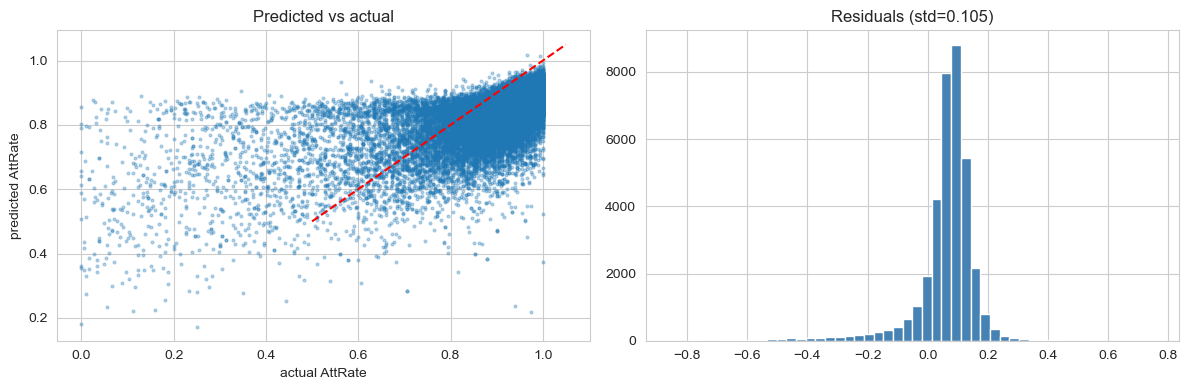

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_reg_test, y_reg_pred, s=4, alpha=0.3)
axes[0].plot([0.5, 1.05], [0.5, 1.05], 'r--')
axes[0].set_xlabel('actual AttRate'); axes[0].set_ylabel('predicted AttRate')
axes[0].set_title('Predicted vs actual')

residuals = y_reg_test - y_reg_pred
axes[1].hist(residuals, bins=50, color='steelblue')
axes[1].set_title(f'Residuals (std={residuals.std():.3f})')
plt.tight_layout(); plt.show()

In [16]:
# Derive chronic_level from predicted AttRate so we can compare with the classifiers
y_clf_from_lin = to_level(pd.Series(y_reg_pred.clip(0, 1))).astype(int)
print('LinearReg-derived chronic_level classification report:')
print(classification_report(y_clf_test, y_clf_from_lin,
                            target_names=[LEVEL_NAMES[i] for i in sorted(LEVEL_NAMES)]))

LinearReg-derived chronic_level classification report:
                    precision    recall  f1-score   support

      Satisfactory       0.92      0.01      0.01     12075
           At-risk       0.26      0.10      0.15     11779
Moderately chronic       0.19      0.59      0.28      7226
  Severely chronic       0.40      0.67      0.50      4837

          accuracy                           0.25     35917
         macro avg       0.44      0.34      0.24     35917
      weighted avg       0.49      0.25      0.18     35917



## 8. Baseline 2 — Multinomial logistic regression on `chronic_level`

In [17]:
def classification_metrics(y_true, y_pred, y_proba=None):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_precision': p,
        'macro_recall': r,
        'macro_f1': f,
    }
    if y_proba is not None:
        try:
            metrics['macro_auc'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        except Exception:
            metrics['macro_auc'] = np.nan
    return metrics


logreg = LogisticRegression(
    multi_class='multinomial', solver='lbfgs', max_iter=2000,
    class_weight='balanced', random_state=SEED,
)
logreg.fit(X_train_imp, y_clf_train)
lr_pred = logreg.predict(X_test_imp)
lr_proba = logreg.predict_proba(X_test_imp)

lr_metrics = classification_metrics(y_clf_test, lr_pred, lr_proba)
print('Logistic regression on chronic_level:')
for k, v in lr_metrics.items():
    print(f'  {k}: {v:.4f}')
print()
print(classification_report(y_clf_test, lr_pred,
                            target_names=[LEVEL_NAMES[i] for i in sorted(LEVEL_NAMES)]))

Logistic regression on chronic_level:
  accuracy: 0.2539
  macro_precision: 0.3897
  macro_recall: 0.3550
  macro_f1: 0.2392
  macro_auc: 0.6484

                    precision    recall  f1-score   support

      Satisfactory       0.75      0.00      0.00     12075
           At-risk       0.27      0.16      0.21     11779
Moderately chronic       0.19      0.46      0.27      7226
  Severely chronic       0.35      0.79      0.48      4837

          accuracy                           0.25     35917
         macro avg       0.39      0.36      0.24     35917
      weighted avg       0.43      0.25      0.19     35917



## 9. Advanced classifiers

Decision Tree, Random Forest, XGBoost, CatBoost — all predicting `chronic_level`. XGBoost and CatBoost handle NaN natively; DT and RF use the −1 sentinel matrix.

In [18]:
results = {'LinearReg→level': classification_metrics(y_clf_test, y_clf_from_lin),
           'LogisticReg': lr_metrics}
fitted = {}

In [19]:
# ---- Decision Tree ----
dt = DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=SEED)
dt.fit(X_train_raw, y_clf_train)
dt_proba = dt.predict_proba(X_test_raw)
dt_pred = dt.predict(X_test_raw)
results['DecisionTree'] = classification_metrics(y_clf_test, dt_pred, dt_proba)
fitted['DecisionTree'] = dt
print('DecisionTree:', {k: round(v, 4) for k, v in results['DecisionTree'].items()})

DecisionTree: {'accuracy': 0.2345, 'macro_precision': 0.3478, 'macro_recall': 0.3389, 'macro_f1': 0.2163, 'macro_auc': np.float64(0.6066)}


In [20]:
# ---- Random Forest ----
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, class_weight='balanced',
    n_jobs=-1, random_state=SEED,
)
rf.fit(X_train_raw, y_clf_train)
rf_proba = rf.predict_proba(X_test_raw)
rf_pred = rf.predict(X_test_raw)
results['RandomForest'] = classification_metrics(y_clf_test, rf_pred, rf_proba)
fitted['RandomForest'] = rf
print('RandomForest:', {k: round(v, 4) for k, v in results['RandomForest'].items()})

RandomForest: {'accuracy': 0.2772, 'macro_precision': 0.429, 'macro_recall': 0.3698, 'macro_f1': 0.2736, 'macro_auc': np.float64(0.6592)}


In [21]:
# ---- XGBoost (handles NaN natively; pass the un-filled matrix) ----
xgb = XGBClassifier(
    objective='multi:softprob', num_class=4,
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    tree_method='hist', eval_metric='mlogloss',
    random_state=SEED, n_jobs=-1,
)
xgb.fit(X_train, y_clf_train)
xgb_proba = xgb.predict_proba(X_test)
xgb_pred = xgb.predict(X_test)
results['XGBoost'] = classification_metrics(y_clf_test, xgb_pred, xgb_proba)
fitted['XGBoost'] = xgb
print('XGBoost:', {k: round(v, 4) for k, v in results['XGBoost'].items()})

XGBoost: {'accuracy': 0.276, 'macro_precision': 0.3852, 'macro_recall': 0.3733, 'macro_f1': 0.2728, 'macro_auc': np.float64(0.6595)}


In [22]:
# ---- CatBoost (also handles NaN natively) ----
cat = CatBoostClassifier(
    iterations=500, depth=6, learning_rate=0.05,
    loss_function='MultiClass', auto_class_weights='Balanced',
    random_seed=SEED, verbose=False,
)
cat.fit(X_train, y_clf_train)
cat_proba = cat.predict_proba(X_test)
cat_pred = cat.predict(X_test).ravel().astype(int)
results['CatBoost'] = classification_metrics(y_clf_test, cat_pred, cat_proba)
fitted['CatBoost'] = cat
print('CatBoost:', {k: round(v, 4) for k, v in results['CatBoost'].items()})

CatBoost: {'accuracy': 0.227, 'macro_precision': 0.3912, 'macro_recall': 0.3376, 'macro_f1': 0.2098, 'macro_auc': np.float64(0.6396)}


## 10. Model comparison and interpretation

In [23]:
summary = pd.DataFrame(results).T.round(4)
summary = summary.sort_values('macro_f1', ascending=False)
summary

,accuracy,macro_precision,macro_recall,macro_f1,macro_auc
RandomForest,0.2772,0.4290,0.3698,0.2736,0.6592
XGBoost,0.2760,0.3852,0.3733,0.2728,0.6595
LogisticReg,0.2539,0.3897,0.3550,0.2392,0.6484
LinearReg→level,0.2450,0.4409,0.3431,0.2351,NaN
DecisionTree,0.2345,0.3478,0.3389,0.2163,0.6066
CatBoost,0.2270,0.3912,0.3376,0.2098,0.6396


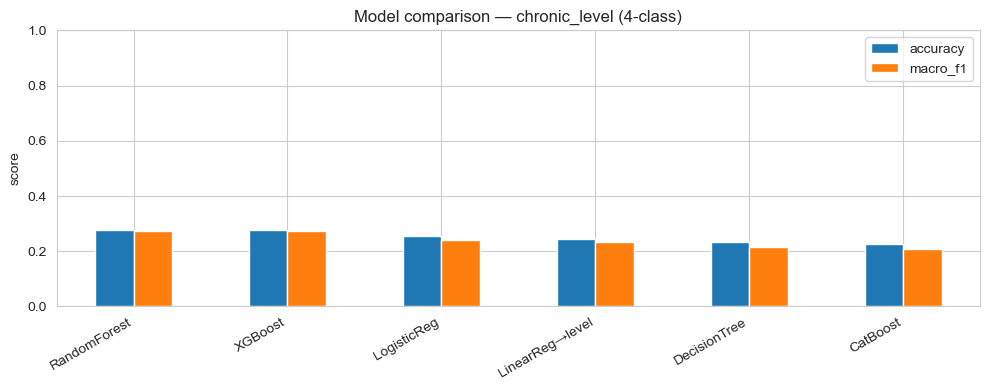

In [24]:
fig, ax = plt.subplots(figsize=(10, 4))
summary[['accuracy', 'macro_f1']].plot(kind='bar', ax=ax)
ax.set_ylabel('score')
ax.set_title('Model comparison — chronic_level (4-class)')
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

Best model: RandomForest


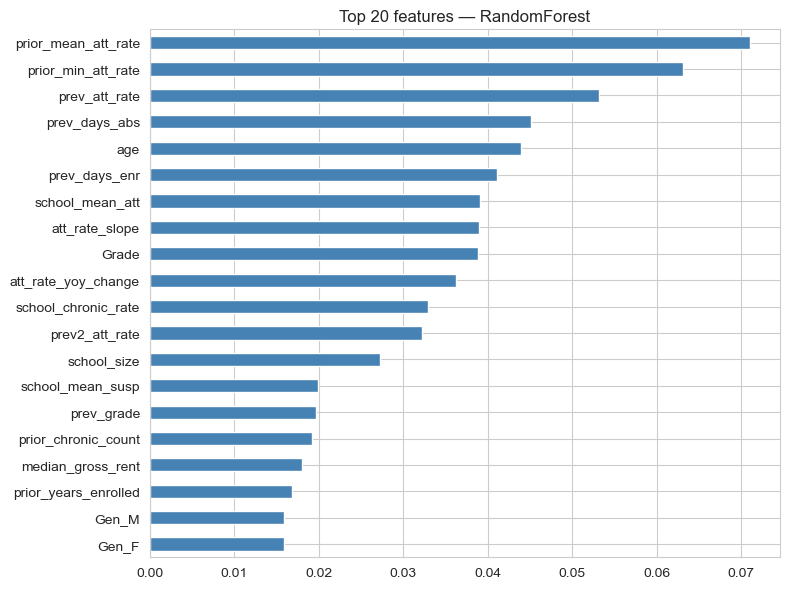

In [25]:
# Feature importance from the best tree model
best_name = summary.index[0]
print(f'Best model: {best_name}')

if best_name in fitted and hasattr(fitted[best_name], 'feature_importances_'):
    fi = pd.Series(fitted[best_name].feature_importances_, index=FEATURE_COLS)
    fi = fi.sort_values(ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(8, 6))
    fi[::-1].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 20 features — {best_name}')
    plt.tight_layout(); plt.show()

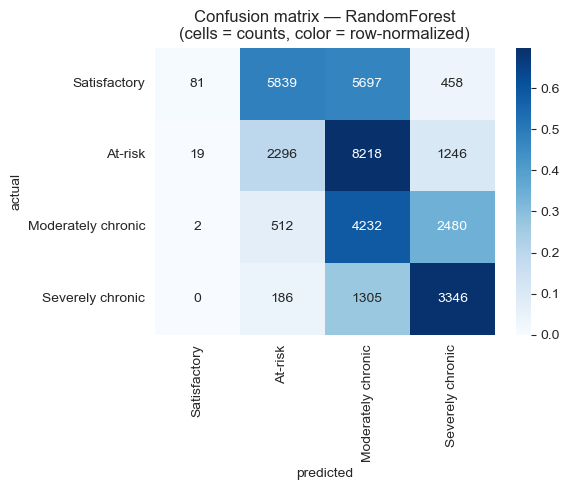

In [26]:
# Confusion matrix for the best model
best_preds = {
    'DecisionTree': dt_pred, 'RandomForest': rf_pred,
    'XGBoost': xgb_pred, 'CatBoost': cat_pred,
    'LogisticReg': lr_pred, 'LinearReg→level': y_clf_from_lin,
}[best_name]
cm = confusion_matrix(y_clf_test, best_preds, labels=[0, 1, 2, 3])
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[LEVEL_NAMES[i] for i in [0, 1, 2, 3]],
            yticklabels=[LEVEL_NAMES[i] for i in [0, 1, 2, 3]])
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title(f'Confusion matrix — {best_name}\n(cells = counts, color = row-normalized)')
plt.tight_layout(); plt.show()

## 11. (Optional) Save artifacts

```python
# import joblib
# joblib.dump(fitted[best_name], REPO_ROOT / 'models' / f'{best_name.lower()}_chronic_level.joblib')
# summary.to_csv(REPO_ROOT / 'reports' / 'model_comparison_chronic_level.csv')
```

Uncomment to persist the best classifier and comparison table.